# Plotting a graph over time of the affilitions

In [25]:
import pandas as pd
import numpy as np
melted_master_condenced = pd.read_excel('/Users/MattJohnson/Desktop/Affiliations/6. Results/6.A. Data created in 6./6.2/JPE_Melted_Weights_applied.xlsx') 
print(melted_master_condenced.shape)
melted_master_condenced = melted_master_condenced[['Article_ID','Weight','Affiliation','year']]
melted_master_condenced = melted_master_condenced.reset_index(drop=True)
melted_master_condenced.head()

(6304, 7)


,Article_ID,Weight,Affiliation,year
0,1825913,1.0,Washington Dc (City),1940
1,1825908,1.0,University Of Chicago,1940
2,1824384,1.0,Columbia University,1940
3,1824382,1.0,Cornell University,1940
4,1824381,1.0,University Of Edinburgh,1940


In [26]:
melted_master_condenced['decade'] = ''
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 1940) & (melted_master_condenced['year'] < 1950), '[1940,1949]', melted_master_condenced['decade'])
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 1950) & (melted_master_condenced['year'] < 1960), '[1950,1959]', melted_master_condenced['decade'])
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 1960) & (melted_master_condenced['year'] < 1970), '[1960,1969]', melted_master_condenced['decade'])
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 1970) & (melted_master_condenced['year'] < 1980), '[1970,1979]', melted_master_condenced['decade'])
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 1980) & (melted_master_condenced['year'] < 1990), '[1980,1989]', melted_master_condenced['decade'])
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 1990) & (melted_master_condenced['year'] < 2000), '[1990,1999]', melted_master_condenced['decade'])
melted_master_condenced['decade'] = np.where((melted_master_condenced['year'] >= 2000) & (melted_master_condenced['year'] < 2011), '[2000,2010]', melted_master_condenced['decade'])
print(melted_master_condenced.head())
print(melted_master_condenced.tail())

   Article_ID  Weight              Affiliation  year       decade
0     1825913     1.0     Washington Dc (City)  1940  [1940,1949]
1     1825908     1.0    University Of Chicago  1940  [1940,1949]
2     1824384     1.0      Columbia University  1940  [1940,1949]
3     1824382     1.0       Cornell University  1940  [1940,1949]
4     1824381     1.0  University Of Edinburgh  1940  [1940,1949]
      Article_ID    Weight                          Affiliation  year  \
6299      653137  0.166667                University Of Bristol  2010   
6300      650305  0.500000                University Of Toronto  2010   
6301      652462  1.000000                University Of Chicago  2010   
6302      657949  0.333333  Federal Reserve Bank Of Minneapolis  2010   
6303      651513  0.500000                Georgetown University  2010   

           decade  
6299  [2000,2010]  
6300  [2000,2010]  
6301  [2000,2010]  
6302  [2000,2010]  
6303  [2000,2010]  


# Ranking the Universities based on their number of papers per published per decade

In [27]:
#Gets the top 10 overall
melted_master_condenced = melted_master_condenced.sort_values(by=['year'])
melted_master_condenced['aff_cum_sum'] = melted_master_condenced.groupby(['Affiliation'])['Weight'].cumsum()

mask_journal = melted_master_condenced['Affiliation'].isin(['National Bureau Of Economic Research'])
melted_master_condenced = melted_master_condenced[~mask_journal]

highest_vals = melted_master_condenced.drop_duplicates(subset = ['Affiliation'], keep = 'last')
highest_vals_10 = highest_vals.nlargest(25,'aff_cum_sum')
print(highest_vals_10.shape)
#print(highest_vals_10.head())
print(highest_vals_10.iat[6,2])

melted_master_condenced_decade = melted_master_condenced[['Article_ID','Weight','Affiliation','decade']]

a = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[6,2]]
a['aff_cum_counts_yearly'] = a.groupby(['Affiliation','decade'])['Weight'].cumsum()
a = a.drop_duplicates(subset = ['decade'], keep = 'last')
print(a.head())
print(a.shape)

(25, 6)
University Of Pennsylvania


      Article_ID    Weight                 Affiliation       decade  \
89       1825228  0.333333  University Of Pennsylvania  [1940,1949]   
706      1825393  1.000000  University Of Pennsylvania  [1950,1959]   
1375     1830033  0.500000  University Of Pennsylvania  [1960,1969]   
2749     1833329  0.500000  University Of Pennsylvania  [1970,1979]   
3756     1831319  0.333333  University Of Pennsylvania  [1980,1989]   

      aff_cum_counts_yearly  
89                 1.000000  
706                3.000000  
1375               8.000000  
2749              13.583333  
3756              18.750000  
(7, 5)


/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_1601/1670870116.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  a['aff_cum_counts_yearly'] = a.groupby(['Affiliation','decade'])['Weight'].cumsum()


In [28]:
a = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[0,2]]
a['aff_cum_sum_decade'] = a.groupby(['Affiliation','decade'])['Weight'].cumsum()
a = a.drop_duplicates(subset = ['decade'], keep = 'last')
print(a.shape)

b = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[1,2]]
b['aff_cum_sum_decade'] = b.groupby(['Affiliation','decade'])['Weight'].cumsum()
b = b.drop_duplicates(subset = ['decade'], keep = 'last')
print(b.shape)

c = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[2,2]]
c['aff_cum_sum_decade'] = c.groupby(['Affiliation','decade'])['Weight'].cumsum()
c = c.drop_duplicates(subset = ['decade'], keep = 'last')
print(c.shape)

d = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[3,2]]
d['aff_cum_sum_decade'] = d.groupby(['Affiliation','decade'])['Weight'].cumsum()
d = d.drop_duplicates(subset = ['decade'], keep = 'last')
print(d.shape)

e = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[4,2]]
e['aff_cum_sum_decade'] = e.groupby(['Affiliation','decade'])['Weight'].cumsum()
e = e.drop_duplicates(subset = ['decade'], keep = 'last')
print(e.shape)

f = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[5,2]]
f['aff_cum_sum_decade'] = f.groupby(['Affiliation','decade'])['Weight'].cumsum()
f = f.drop_duplicates(subset = ['decade'], keep = 'last')
print(f.shape)

g = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[6,2]]
g['aff_cum_sum_decade'] = g.groupby(['Affiliation','decade'])['Weight'].cumsum()
g = g.drop_duplicates(subset = ['decade'], keep = 'last')
print(g.shape)

h = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[7,2]]
h['aff_cum_sum_decade'] = h.groupby(['Affiliation','decade'])['Weight'].cumsum()
h = h.drop_duplicates(subset = ['decade'], keep = 'last')
print(h.shape)

i = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[8,2]]
i['aff_cum_sum_decade'] = i.groupby(['Affiliation','decade'])['Weight'].cumsum()
i = i.drop_duplicates(subset = ['decade'], keep = 'last')
print(i.shape)

j = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[9,2]]
j['aff_cum_sum_decade'] = j.groupby(['Affiliation','decade'])['Weight'].cumsum()
j = j.drop_duplicates(subset = ['decade'], keep = 'last')
print(j.shape)

k = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[10,2]]
k['aff_cum_sum_decade'] = k.groupby(['Affiliation','decade'])['Weight'].cumsum()
k = k.drop_duplicates(subset = ['decade'], keep = 'last')
print(k.shape)

l = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[11,2]]
l['aff_cum_sum_decade'] = l.groupby(['Affiliation','decade'])['Weight'].cumsum()
l = l.drop_duplicates(subset = ['decade'], keep = 'last')
print(l.shape)

m = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[12,2]]
m['aff_cum_sum_decade'] = m.groupby(['Affiliation','decade'])['Weight'].cumsum()
m = m.drop_duplicates(subset = ['decade'], keep = 'last')
print(m.shape)

n = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[13,2]]
n['aff_cum_sum_decade'] = n.groupby(['Affiliation','decade'])['Weight'].cumsum()
n = n.drop_duplicates(subset = ['decade'], keep = 'last')
print(n.shape)

o = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[14,2]]
o['aff_cum_sum_decade'] = o.groupby(['Affiliation','decade'])['Weight'].cumsum()
o = o.drop_duplicates(subset = ['decade'], keep = 'last')
print(o.shape)

p = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[15,2]]
p['aff_cum_sum_decade'] = p.groupby(['Affiliation','decade'])['Weight'].cumsum()
p = p.drop_duplicates(subset = ['decade'], keep = 'last')
print(p.shape)

q = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[16,2]]
q['aff_cum_sum_decade'] = q.groupby(['Affiliation','decade'])['Weight'].cumsum()
q = q.drop_duplicates(subset = ['decade'], keep = 'last')
print(q.shape)

r = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[17,2]]
r['aff_cum_sum_decade'] = r.groupby(['Affiliation','decade'])['Weight'].cumsum()
r = r.drop_duplicates(subset = ['decade'], keep = 'last')
print(r.shape)

s = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[18,2]]
s['aff_cum_sum_decade'] = s.groupby(['Affiliation','decade'])['Weight'].cumsum()
s = s.drop_duplicates(subset = ['decade'], keep = 'last')
print(s.shape)

t = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[19,2]]
t['aff_cum_sum_decade'] = t.groupby(['Affiliation','decade'])['Weight'].cumsum()
t = t.drop_duplicates(subset = ['decade'], keep = 'last')
print(t.shape)

u = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[20,2]]
u['aff_cum_sum_decade'] = u.groupby(['Affiliation','decade'])['Weight'].cumsum()
u = u.drop_duplicates(subset = ['decade'], keep = 'last')
print(u.shape)

v = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[21,2]]
v['aff_cum_sum_decade'] = v.groupby(['Affiliation','decade'])['Weight'].cumsum()
v = v.drop_duplicates(subset = ['decade'], keep = 'last')
print(v.shape)

w = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[22,2]]
w['aff_cum_sum_decade'] = w.groupby(['Affiliation','decade'])['Weight'].cumsum()
w = w.drop_duplicates(subset = ['decade'], keep = 'last')
print(w.shape)

x = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[23,2]]
x['aff_cum_sum_decade'] = x.groupby(['Affiliation','decade'])['Weight'].cumsum()
x = x.drop_duplicates(subset = ['decade'], keep = 'last')
print(x.shape)

y = melted_master_condenced_decade.loc[melted_master_condenced_decade['Affiliation'] == highest_vals_10.iat[24,2]]
y['aff_cum_sum_decade'] = y.groupby(['Affiliation','decade'])['Weight'].cumsum()
y = y.drop_duplicates(subset = ['decade'], keep = 'last')
print(y.shape)

(7, 5)


/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_1601/1100585584.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  a['aff_cum_sum_decade'] = a.groupby(['Affiliation','decade'])['Weight'].cumsum()
/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_1601/1100585584.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  b['aff_cum_sum_decade'] = b.groupby(['Affiliation','decade'])['Weight'].cumsum()
/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_1601/1100585584.py:12: SettingWithCop

(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)
(7, 5)


/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_1601/1100585584.py:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  m['aff_cum_sum_decade'] = m.groupby(['Affiliation','decade'])['Weight'].cumsum()
/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_1601/1100585584.py:67: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  n['aff_cum_sum_decade'] = n.groupby(['Affiliation','decade'])['Weight'].cumsum()
/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_1601/1100585584.py:72: SettingWithC

(7, 5)
(7, 5)
(7, 5)
(5, 5)
(7, 5)
(7, 5)
(6, 5)
(6, 5)
(4, 5)
(6, 5)
(7, 5)
(5, 5)
(6, 5)


/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_1601/1100585584.py:82: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  q['aff_cum_sum_decade'] = q.groupby(['Affiliation','decade'])['Weight'].cumsum()
/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_1601/1100585584.py:87: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  r['aff_cum_sum_decade'] = r.groupby(['Affiliation','decade'])['Weight'].cumsum()
/var/folders/23/ft9qf9c11rj_vqhbjml910f40000gn/T/ipykernel_1601/1100585584.py:92: SettingWithC

In [29]:
#ranked = pd.concat([a,b,c,d,e,f,g,h,i,j], axis=0)
#ranked = pd.concat([a,b,c,d,e,f,g,h,i,j,k,l,m,n,o], axis=0)
#ranked = pd.concat([a,b,c,d,e,f,g,h,i,j,k,l,m,n,o,p,q,r,s,t], axis=0)
ranked = pd.concat([a,b,c,d,e,f,g,h,i,j,k,l,m,n,o,p,q,r,s,t,u,v,w,x,y], axis=0)
ranked = ranked.sort_values(by=['decade','Affiliation'])
print(ranked.shape)

ranked['Rank'] = ranked.groupby(['decade'])['aff_cum_sum_decade'].rank(method = 'max', ascending= False)
print(ranked.shape)
print(ranked.tail(20))
#ranked.to_excel('/Users/MattJohnson/Desktop/Affiliations/2_Extracting affilitations/2_Fuzzy matching/Combined journals/Combined journal yearly rank.xlsx') 

(164, 5)
(164, 6)
      Article_ID    Weight                                     Affiliation  \
6186      644840  0.500000                  Hebrew University Of Jerusalem   
6220      653137  0.250000  London School Of Economics & Political Science   
6296      653714  0.333333           Massachusetts Institute Of Technology   
6237      653452  0.250000                             New York University   
6283      658161  0.250000                         Northwestern University   
5679      421173  0.166667                           Ohio State University   
6295      653138  0.333333                            Princeton University   
6249      651673  0.250000                             Stanford University   
6251      653714  0.333333              University Of California, Berkeley   
6224      653690  0.250000           University Of California, Los Angeles   
6301      652462  1.000000                           University Of Chicago   
6113      649760  0.166667                    

In [30]:
#ranked.to_excel('/Users/MattJohnson/Desktop/Affiliations/6. Results/6.A. Data created in 6./6.3/JPE_Ranked_data.xlsx') 

In [41]:
ranked = ranked.rename(columns={"decade": "Year Bucket"})
ranked

,Article_ID,Weight,Affiliation,Year Bucket,aff_cum_sum_decade,Rank
330,1825619,1.000000,Carnegie Mellon University,"[1940,1949]",4.0,14.0
315,1826272,1.000000,Columbia University,"[1940,1949]",10.0,5.0
327,1825623,1.000000,Duke University,"[1940,1949]",9.0,7.0
324,1825186,0.500000,Harvard University,"[1940,1949]",10.0,5.0
207,1827064,0.500000,Massachusetts Institute Of Technology,"[1940,1949]",6.0,8.0
...,...,...,...,...,...,...
5832,500279,1.000000,University Of Virginia,"[2000,2010]",1.2,22.0
5261,340777,0.500000,University Of Washington,"[2000,2010]",1.0,23.0
5140,322083,1.000000,University Of Western Ontario,"[2000,2010]",2.0,21.0
6178,599014,0.166667,University Of Wisconsin,"[2000,2010]",0.9,24.0


In [32]:
pivot = ranked.pivot(index='Year Bucket', columns='Affiliation', values='Rank')
pivot

Affiliation,Carnegie Mellon University,Columbia University,Duke University,Harvard University,Hebrew University Of Jerusalem,London School Of Economics & Political Science,Massachusetts Institute Of Technology,New York University,Northwestern University,Ohio State University,...,University Of Michigan,University Of Minnesota,University Of Pennsylvania,University Of Rochester,University Of Virginia,University Of Washington,University Of Western Ontario,University Of Wisconsin,Washington Dc (City),Yale University
Year Bucket,,,,,,,,,,,,,,,,,,,,,
"[1940,1949]",14.0,5.0,7.0,5.0,NaN,NaN,8.0,7.0,16.0,14.0,...,12.0,17.0,20.0,NaN,12.0,NaN,NaN,16.0,2.0,20.0
"[1950,1959]",16.0,6.0,3.0,14.0,21.0,19.0,2.0,23.0,11.0,22.0,...,6.0,17.0,19.0,NaN,13.0,11.0,NaN,8.0,20.0,11.0
"[1960,1969]",4.0,7.0,24.0,16.0,24.0,9.0,2.0,24.0,5.0,21.0,...,20.0,6.0,18.0,17.0,12.0,15.0,20.0,15.0,25.0,3.0
"[1970,1979]",19.0,3.0,22.0,2.0,8.0,12.0,6.0,16.0,21.0,17.0,...,18.0,20.0,14.0,11.0,13.0,7.0,24.0,15.0,25.0,9.0
"[1980,1989]",8.0,13.0,22.0,4.0,20.0,21.0,2.0,19.0,11.0,12.0,...,17.0,18.0,6.0,14.0,9.0,23.0,5.0,24.0,NaN,10.0
"[1990,1999]",14.0,19.0,16.0,3.0,23.0,15.0,2.0,11.0,7.0,22.0,...,10.0,12.0,4.0,8.0,21.0,19.0,20.0,NaN,NaN,17.0
"[2000,2010]",18.0,9.0,14.0,3.0,17.0,20.0,2.0,8.0,5.0,19.0,...,11.0,16.0,4.0,15.0,22.0,23.0,21.0,24.0,NaN,13.0


In [33]:
pivot_ordered = pivot[['University Of Chicago','Massachusetts Institute Of Technology','Harvard University','University Of Pennsylvania','Northwestern University','Princeton University','Stanford University','Columbia University', 'University Of California, Los Angeles','Yale University']]
pivot_ordered

Affiliation,University Of Chicago,Massachusetts Institute Of Technology,Harvard University,University Of Pennsylvania,Northwestern University,Princeton University,Stanford University,Columbia University,"University Of California, Los Angeles",Yale University
Year Bucket,,,,,,,,,,
"[1940,1949]",1.0,8.0,5.0,20.0,16.0,3.0,12.0,5.0,20.0,20.0
"[1950,1959]",1.0,2.0,14.0,19.0,11.0,16.0,4.0,6.0,12.0,11.0
"[1960,1969]",1.0,2.0,16.0,18.0,5.0,8.0,10.0,7.0,15.0,3.0
"[1970,1979]",1.0,6.0,2.0,14.0,21.0,5.0,10.0,3.0,4.0,9.0
"[1980,1989]",1.0,2.0,4.0,6.0,11.0,7.0,4.0,13.0,15.0,10.0
"[1990,1999]",1.0,2.0,3.0,4.0,7.0,6.0,5.0,19.0,9.0,17.0
"[2000,2010]",1.0,2.0,3.0,4.0,5.0,6.0,7.0,9.0,10.0,13.0


In [34]:
ranked['aff_cum_sum_decade'] = ranked['aff_cum_sum_decade'].apply(lambda x: round(x, 1))
pivot2 = ranked.pivot(index='Year Bucket', columns='Affiliation', values='aff_cum_sum_decade')
pivot2_ordered = pivot2[['University Of Chicago','Massachusetts Institute Of Technology','Harvard University','University Of Pennsylvania','Northwestern University','Princeton University','Stanford University','Columbia University', 'University Of California, Los Angeles','Yale University']]

pivot2_ordered

Affiliation,University Of Chicago,Massachusetts Institute Of Technology,Harvard University,University Of Pennsylvania,Northwestern University,Princeton University,Stanford University,Columbia University,"University Of California, Los Angeles",Yale University
Year Bucket,,,,,,,,,,
"[1940,1949]",46.0,6.0,10.0,1.0,3.0,11.0,5.0,10.0,1.0,1.0
"[1950,1959]",44.5,16.0,6.0,3.0,8.0,5.0,12.5,11.0,7.5,8.0
"[1960,1969]",60.1,19.9,8.3,8.0,12.5,11.5,10.2,11.8,9.0,19.8
"[1970,1979]",64.8,21.0,34.5,13.6,7.9,21.5,17.8,23.7,21.8,19.0
"[1980,1989]",39.2,24.6,20.2,18.8,13.8,17.1,20.2,11.2,10.1,14.7
"[1990,1999]",42.0,20.1,19.6,17.4,11.9,13.0,16.8,3.8,9.8,4.0
"[2000,2010]",37.7,16.1,15.4,12.8,12.3,12.2,11.3,9.2,8.9,6.5


In [42]:

invert_pivot = ranked.pivot(index='Affiliation', columns='Year Bucket', values='aff_cum_sum_decade')

invert_pivot['Total papers'] = invert_pivot.sum(axis=1)
invert_pivot['Average Paper per decade'] = invert_pivot.mean(axis=1)
invert_pivot['Total papers'] = invert_pivot['Total papers'].astype(int)
invert_pivot['Average Paper per decade'] = invert_pivot['Average Paper per decade'].astype(int)

invert_pivot['[1940,1949]'] = invert_pivot['[1940,1949]'].fillna(0).astype(int)
invert_pivot['[1950,1959]'] = invert_pivot['[1950,1959]'].fillna(0).astype(int)
invert_pivot['[1960,1969]'] = invert_pivot['[1960,1969]'].fillna(0).astype(int)
invert_pivot['[1970,1979]'] = invert_pivot['[1970,1979]'].fillna(0).astype(int)
invert_pivot['[1980,1989]'] = invert_pivot['[1980,1989]'].fillna(0).astype(int)
invert_pivot['[1990,1999]'] = invert_pivot['[1990,1999]'].fillna(0).astype(int)
invert_pivot['[2000,2010]'] = invert_pivot['[2000,2010]'].fillna(0).astype(int)

invert_pivot = invert_pivot.sort_values(by='Total papers', ascending=False)
#invert_pivot = invert_pivot.reset_index(drop=True)
#invert_pivot = invert_pivot.drop('Year Bucket', axis=1)
invert_pivot
invert_pivot.to_excel('/Users/MattJohnson/Desktop/Affiliations/6. Results/6.3. Rankings per decade/JPE pivot.xlsx') 

<AxesSubplot: xlabel='Year Bucket', ylabel='Affiliation'>

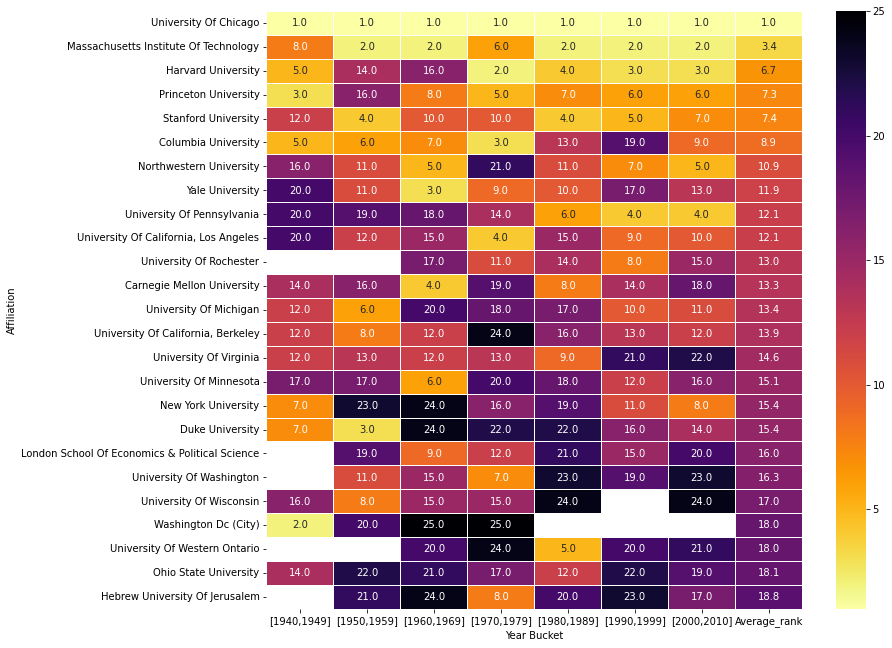

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt


ranked = ranked.replace(0, '')
invert_pivot = ranked.pivot(index='Affiliation', columns='Year Bucket', values='Rank')
invert_pivot['Average_rank'] = invert_pivot.mean(axis=1)

invert_pivot = invert_pivot.sort_values(by='Average_rank', ascending=True)


f, ax = plt.subplots(figsize=(12, 11))
cmap = plt.get_cmap('inferno_r')
sns.heatmap(invert_pivot, annot=True, fmt=".1f", cmap = cmap, linewidths=.5, ax=ax)

Year Bucket                                     [1940,1949]  [1950,1959]  \
Affiliation                                                                
Carnegie Mellon University                              4.0          5.0   
Columbia University                                    10.0         11.0   
Duke University                                         9.0         14.0   
Harvard University                                     10.0          6.0   
Hebrew University Of Jerusalem                          NaN          2.0   
London School Of Economics & Political Science          NaN          3.0   
Massachusetts Institute Of Technology                   6.0         16.0   
New York University                                     9.0          1.0   
Northwestern University                                 3.0          8.0   
Ohio State University                                   4.0          1.5   
Princeton University                                   11.0          5.0   
Stanford Uni

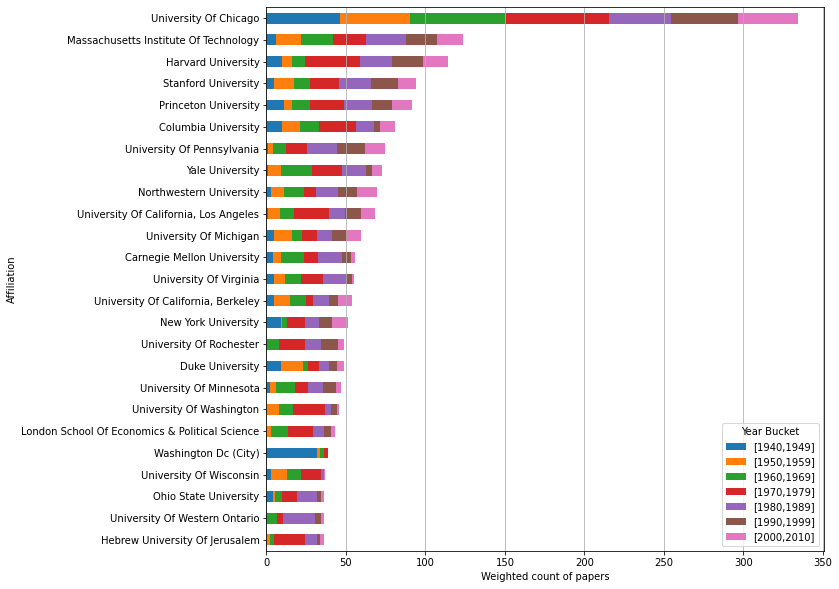

In [37]:
p = ranked.pivot(index='Affiliation', columns='Year Bucket', values='aff_cum_sum_decade')
print(p)
p['sum_cols'] = p.sum(axis=1)
p = p.sort_values(by='sum_cols', ascending=True)
p = p.drop(['sum_cols'], axis=1)

ax = p.plot.barh(stacked=True, figsize=(10, 10))
#plt.xticks(np.arange(0, 375, step=25))
plt.xlabel('Weighted count of papers')
plt.grid(axis = 'x')
plt.show()
